<a href="https://colab.research.google.com/github/Cooljoe67/ML_DSAI/blob/main/UML_Day_3_Warmup__Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Run this but don't look at this !

In [3]:
# @title
# Setup the data
import pandas as pd

# Load real data
# ID of the Google Sheet for student food preferences
sheet_id = "1pBjQzLm1zdsbH_zr099nNkC1rLQmzUrN"

# Title of the Google Sheet
sheet_name = "1937353490"

# URL to download the Google Sheet as a CSV
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_name}"

# Create a Pandas DataFrame from the CSV data
foods_df = pd.read_csv(url, index_col="student")

# Drop columns not usefull
foods_df = foods_df.drop(columns=["age","favorite_color"])

# Generate fake data and define plotting functions

from sklearn.datasets import make_blobs


centers = [
    (1, 1, 8, 2, 8, 3, 2, 4, 600),
    (5, 3, 4, 1, 7, 4, 6, 8, 900),
    (6, 3, 9, 5, 8, 6, 7, 7, 400),
    (2, 6, 7, 3, 5, 2, 8, 5, 30),
    (7, 8, 2, 6, 3, 9, 5, 2, 800)
]
X, y = make_blobs(n_samples=80, centers=centers, cluster_std=2, random_state=42)

# Create a new DataFrame with all rows from X and the same columns as foods_df
fake_df = pd.DataFrame(X, columns=foods_df.columns)


easy_X, easy_y = make_blobs(n_samples=80, centers=centers, cluster_std=.5, random_state=42)

easy_df = pd.DataFrame(easy_X, columns=foods_df.columns)

#### The data for this warmup is called fake_df

In [4]:
# @title
# A small explorative plotting function

import random
import matplotlib.pyplot as plt

def rand_plot_2d(df):
    c1, c2 = random.randint(0, len(df.columns)-1), random.randint(0, len(df.columns)-1)
    plt.scatter(x=df.iloc[:, c1], y=df.iloc[:, c2])
    plt.xlabel(df.columns[c1])
    plt.ylabel(df.columns[c2])
    plt.show()

Here I prepared a random plot that picks two random dimensions and plots the data in a scatterplot. Do you see any clusters?

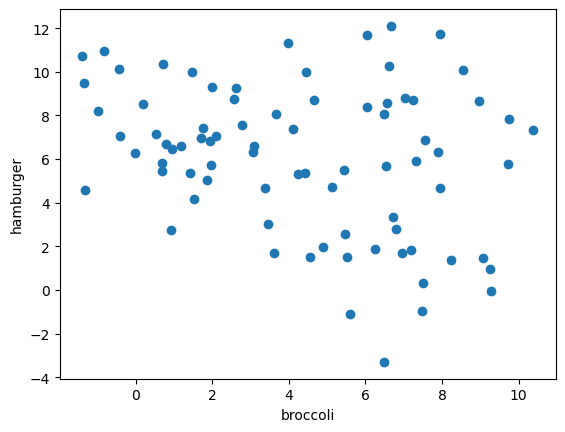

In [5]:
rand_plot_2d(fake_df)

####Exercise 1: Import a scaler and initialize it

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer, PowerTransformer
from sklearn import set_config

set_config(transform_output="pandas")

mimaScaler = StandardScaler()

mimaScaler

,copy,True
,with_mean,True
,with_std,True


#####Hint:

Google "sklearn" + the scaler you want to use to find the scaler's documentation<br>
At the very top it says `class sklearn.______.______(`... This is kind of like a file path telling us where to find the model in the library. So to import it we run `from sklearn.______ import ______`.<br><br>
To initialize the scaler we call it like a function and assign the result to a variable: `scaler = ______()`

####Exercise 2: Scale fake df using your scaler

In [7]:
old_fake_df = fake_df.copy()
mimaScaler.fit_transform(fake_df)
old_fake_df

,broccoli,brussels_sprouts,hamburger,oysters (raw),onion (raw),peas,olives,blue_cheese,whisky
0,8.555330,1.816857,10.094195,4.595615,7.564638,8.197554,8.650833,8.627019,402.610958
1,6.806574,6.910162,2.798272,5.924731,5.206604,9.228455,5.300604,1.272776,799.886109
2,1.515101,0.851108,4.162458,1.946972,8.120460,7.926484,1.615278,4.603095,599.930576
3,1.934611,1.865116,6.821760,0.391061,6.339345,2.733196,6.120240,3.972266,27.881573
4,7.245700,0.864759,8.715241,5.240591,9.028878,7.423230,4.750716,3.931772,402.555354
...,...,...,...,...,...,...,...,...,...
75,3.454350,2.526363,3.029273,1.163748,11.629317,0.265470,7.372520,4.774568,899.056136
76,7.496441,7.081278,0.300311,7.660672,1.287832,9.143132,4.044685,2.957960,800.667324
77,8.950712,4.715319,8.680123,4.961968,5.994941,5.962974,6.422683,7.645437,398.345538
78,0.928348,4.129287,2.760510,3.643805,8.174094,2.401985,2.183522,0.024862,599.560656


#####Hint:

`.fit_transform(data)`

####Exercise 3: Initialize a K-means model and fit it to the scaled data

In [8]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=4)
model.fit(fake_df)

c:\Users\Marcus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


#####Hint:

Google "sklearn kmeans" to find the documentation so you can see where to import it from
```
from sklearn._________ import Kmeans
model = _________(n_clusters=____)
model.fit(data)
```

####Exercise 4: Extract the labels from the fit model, add them to the original data frame, and sort it by the cluster assignments to more easily see the groupings

In [ ]:
fake_df['label'] = model.labels_
fake_df.sort_values(by="label")

,broccoli,brussels_sprouts,hamburger,oysters (raw),onion (raw),peas,olives,blue_cheese,whisky,label
79,-1.337356,3.285646,9.503866,3.582064,6.181225,5.805589,-0.803702,5.173714,604.380911,3
12,4.099869,-0.566507,7.355877,3.627034,5.538271,3.454920,4.614286,0.785034,600.369268,3
37,2.085120,0.073165,7.068540,2.483925,4.173440,-0.449836,0.875425,1.974338,600.628495,3
36,1.993428,0.723471,9.295377,5.046060,7.531693,2.531726,5.158426,5.534869,599.061051,3
42,1.714225,3.955788,6.963460,0.383013,6.996486,4.830804,2.657502,2.940480,601.026535,3
...,...,...,...,...,...,...,...,...,...,...
56,5.116417,0.714059,4.715575,2.121569,9.166102,6.107604,3.244661,6.124350,901.030071,0
58,3.615071,11.059101,1.683984,5.146238,0.975791,5.690287,6.646341,2.146636,797.420078,0
59,7.471229,9.541730,-0.957172,8.287508,3.676993,8.169424,6.265564,6.541386,800.363733,0
38,6.731510,0.599407,3.330998,0.050109,5.693342,7.530908,6.809963,5.478232,901.835724,0


#####Hint:

`foods_df['cluster'] = model.________`<br>
Check [the attributes section of the KMeans documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#:~:text=instead%20of%20%E2%80%9Celkan%E2%80%9D.-,Attributes%3A,-cluster_centers_ndarray%20of) to see where you can get the model's labels<br><br>
`df.sort_values()`

#### Bonus: Compare scaled cluster labels versus unscaled cluster labels

In [10]:
model.fit(old_fake_df)
old_fake_df["us_label"] = model.labels_

fake_df = fake_df.join(old_fake_df[["us_label"]])

c:\Users\Marcus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
fake_df.sort_values(by="label")

,broccoli,brussels_sprouts,hamburger,oysters (raw),onion (raw),peas,olives,blue_cheese,whisky,label,us_label
50,7.882547,0.128276,6.326328,1.020466,5.036983,4.924207,6.398119,6.799566,900.139604,0,0
61,7.559937,5.749022,6.891504,6.258442,3.218790,10.451533,5.962018,2.447768,798.419051,0,0
62,5.519766,4.563646,1.526099,-1.640913,8.043883,4.593969,6.500986,8.692896,898.639951,0,0
29,4.229373,3.227035,5.324261,4.172034,4.524369,8.266067,2.095824,7.696430,901.176634,0,0
28,6.490046,11.007986,-3.301940,8.183014,5.492170,4.853220,4.314625,1.257118,797.184977,0,0
...,...,...,...,...,...,...,...,...,...,...,...
78,0.928348,4.129287,2.760510,3.643805,8.174094,2.401985,2.183522,0.024862,599.560656,3,2
37,2.085120,0.073165,7.068540,2.483925,4.173440,-0.449836,0.875425,1.974338,600.628495,3,2
30,-1.392413,2.625052,10.712480,1.855980,10.007066,3.723272,0.709760,4.722791,603.076073,3,2
36,1.993428,0.723471,9.295377,5.046060,7.531693,2.531726,5.158426,5.534869,599.061051,3,2


#####Hint:

Iterate the above but without scaling the data.